# master_25_07_v1

Bản nâng cấp từ `master_15_07_v2` (multiple task), cải tiến độ chính xác của từng nhãn tiệm cận với các model single-task (được kế thừa từ các cải tiến trong các bản `master_20_07_single_task_result` và `master_24_07_result`):

## Các cải tiến chính:
1. **Hidden Fusion (Trộn các tầng ẩn)**: Thay vì chỉ dùng tầng ẩn cuối cùng của PhoBERT, ta trích xuất và tính trung bình cộng đầu ra của **4 tầng cuối** (`hidden_states[-4:]`). Điều này giúp biểu diễn ngữ nghĩa phong phú và ổn định hơn trước khi đưa vào các aspect attention và classifiers.
2. **Adversarial Training (FGM)**: Tích hợp phương pháp huấn luyện đối nghịch Fast Gradient Method (FGM) bắt đầu từ epoch 2 với $\epsilon = 0.15$ trên `word_embeddings` của PhoBERT backbone. FGM hoạt động như một bộ regularization mạnh mẽ, giúp chống overfit và cải thiện đáng kể khả năng generalize trên cả 4 khía cạnh cùng lúc.
3. **Tuning Aspect-Specific Hyperparameters**: Cân chỉnh lại hệ số boosting lớp thiểu số (`negative_boost_factors`) và trọng số phạt margin (`margin_loss_weights`) tương thích với các giá trị tối ưu của các model single-task tại `24_07_result` để cân bằng giữa Precision và Recall (đặc biệt ở Atmosphere và Food quality):
   - **Atmosphere**: Giảm `negative_boost` từ 1.85 xuống **1.45**, `margin_loss_weight` từ 0.60 xuống **0.40** (để tăng precision cho lớp Negative, giảm tỉ lệ nhận nhầm mẫu khác thành Negative).
   - **Food quality**: `negative_boost` xuống **1.25** (từ 1.30), `margin_loss_weight` xuống **0.20** (từ 0.25).
   - **Service quality**: Giữ nguyên `negative_boost` **1.35** và `margin_loss_weight` **0.30**.

## Cách chạy
1. Chạy cell 1 (huấn luyện) - xuất ra `best_phobert_absa_v25_07.pth`, `master_25_07_report.json`, `master_25_07_confusion.png`, `master_25_07_history.png`.
2. Chạy cell 2 (đánh giá) - vẽ lại biểu đồ history đầy đủ, load checkpoint tốt nhất, in ma trận nhầm lẫn theo % cho cả 4 khía cạnh.


In [1]:
from __future__ import annotations

import copy
import json
import warnings
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.optim import AdamW
from torch.optim.lr_scheduler import SequentialLR
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup

warnings.filterwarnings("ignore")


@dataclass
class Config:
    model_name: str = "vinai/phobert-base-v2"
    data_file: str = "labeled_results_all_v6.json"
    output_dir: str = "."
    seed: int = 42
    max_len: int = 256
    batch_size: int = 64
    epochs: int = 20
    max_lr: float = 1.5e-5
    weight_decay: float = 0.1
    layer_decay: float = 0.9
    warmup_ratio: float = 0.1
    num_workers: int = 0
    label_smoothing: float = 0.08

    # ===== Aspect loss scaling =====
    atmosphere_loss_scale: float = 1.35
    food_loss_scale: float = 1.05
    service_loss_scale: float = 1.10

    # ===== Model regularization =====
    dropout_projection: float = 0.35
    dropout_multisample: Tuple[float, float, float] = (0.15, 0.25, 0.35)
    hidden_projection_size: int = 256

    # ===== Sampler =====
    sampler_clip_min: float = 0.25
    sampler_clip_max: float = 4.0

    # ===== 25/07: per-aspect Negative boosting (Tuned based on single-task 24_07) =====
    negative_boost_factors: Dict[str, float] = field(
        default_factory=lambda: {
            "Food quality": 1.25,
            "Service quality": 1.35,
            "Atmosphere": 1.45,
        }
    )
    sample_weight_max_blend: float = 0.5
    atmosphere_negative_oversample: float = 1.5

    # ===== Focal loss gamma theo từng khía cạnh =====
    focal_gamma_default: float = 2.0
    focal_gamma_atmosphere: float = 2.6

    # ===== 25/07: Margin loss (Tuned weights based on single-task 24_07) =====
    margin_threshold: float = 1.0
    margin_loss_weights: Dict[str, float] = field(
        default_factory=lambda: {
            "Food quality": 0.20,
            "Price": 0.0,
            "Service quality": 0.30,
            "Atmosphere": 0.40,
        }
    )

    # ===== R-Drop-lite =====
    rdrop_alpha: float = 0.6
    rdrop_warmup_epochs: int = 1

    # ===== LR warm-restart =====
    warm_restart_epoch: int = 10
    restart_warmup_ratio: float = 0.08

    # ===== EMA =====
    use_ema: bool = True
    ema_decay: float = 0.999
    ema_start_epoch: int = 3

    # ===== 25/07: FGM (Adversarial Training) =====
    use_fgm: bool = True
    fgm_epsilon: float = 0.15
    fgm_start_epoch: int = 2

    # ===== 25/07: Hidden Fusion =====
    use_hidden_fusion: bool = True


ASPECTS = ["Food quality", "Price", "Service quality", "Atmosphere"]
CLASS_NAMES = ["Negative", "Neutral", "Positive"]


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def map_label(value: float) -> int:
    if value == 0.0:
        return 0
    if value == 0.5:
        return 1
    if value == 1.0:
        return 2
    return 1


def find_data_file(config: Config) -> Path:
    base_dir = Path.cwd()
    candidates = [
        base_dir / config.data_file,
        base_dir.parent / config.data_file,
        Path(config.data_file),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Cannot find data file: {config.data_file}")


def load_dataframe(data_path: Path) -> pd.DataFrame:
    with data_path.open("r", encoding="utf-8") as f:
        raw_data = json.load(f)

    processed: List[Dict[str, int | str]] = []
    for item in raw_data:
        text = item["original_data"]["textTranslated"]
        labels = {entry["name"]: map_label(entry["value"]) for entry in item["labels"]}
        processed.append(
            {
                "text": text,
                "Food quality": labels.get("Food quality", 1),
                "Price": labels.get("Price", 1),
                "Service quality": labels.get("Service quality", 1),
                "Atmosphere": labels.get("Atmosphere", 1),
            }
        )

    df = pd.DataFrame(processed)
    df["stratify_key"] = df[ASPECTS].astype(str).agg("_".join, axis=1)
    return df


def safe_split(df: pd.DataFrame, seed: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    stratify_key = df["stratify_key"]
    if stratify_key.value_counts().min() < 2:
        stratify_key = df["Atmosphere"].astype(str)
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=seed,
        stratify=stratify_key,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)


class RestaurantReviewDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer: AutoTokenizer, max_len: int):
        self.texts = df["text"].values
        self.labels = df[ASPECTS].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        encoding = self.tokenizer(
            str(self.texts[index]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[index], dtype=torch.long),
        }


# ================== FOCAL LOSS ==================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing
        self.ce = nn.CrossEntropyLoss(weight=weight, label_smoothing=label_smoothing, reduction='none')

    def forward(self, input, target):
        ce_loss = self.ce(input, target)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


# ================== MARGIN LOSS FOR NEGATIVE-NEUTRAL PAIR ==================
class NegativeNeutralMarginLoss(nn.Module):
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        neg_mask = targets == 0
        if neg_mask.sum() == 0:
            return logits.new_tensor(0.0)
        logit_neg = logits[neg_mask, 0]
        logit_neu = logits[neg_mask, 1]
        violation = F.relu(self.margin - (logit_neg - logit_neu))
        return violation.mean()


# ====== MODEL WITH ASPECT-SPECIFIC ATTENTION & HIDDEN FUSION ======
class PhoBertABSA(nn.Module):
    def __init__(self, model_name: str, n_classes: int = 3, n_aspects: int = 4,
                 hidden_projection_size: int = 256, dropout_projection: float = 0.35,
                 dropout_multisample: Tuple[float, float, float] = (0.15, 0.25, 0.35),
                 use_hidden_fusion: bool = False):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.use_hidden_fusion = use_hidden_fusion
        hidden_size = self.phobert.config.hidden_size

        # Attention for each aspect
        self.aspect_attentions = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.Tanh(),
                nn.Linear(hidden_size, 1)
            ) for _ in range(n_aspects)
        ])

        self.aspect_projections = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_size * 2, hidden_projection_size),
                    nn.LayerNorm(hidden_projection_size),
                    nn.GELU(),
                    nn.Dropout(dropout_projection),
                )
                for _ in range(n_aspects)
            ]
        )

        self.dropouts = nn.ModuleList([nn.Dropout(p=p) for p in dropout_multisample])
        self.classifiers = nn.ModuleList(
            [nn.Sequential(nn.Linear(hidden_projection_size, n_classes)) for _ in range(n_aspects)]
        )

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        return_views: bool = False,
    ):
        if self.use_hidden_fusion:
            outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
            last_4_layers = outputs.hidden_states[-4:]
            last_hidden = torch.stack(last_4_layers, dim=0).mean(dim=0)
        else:
            outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden = outputs.last_hidden_state  # [batch_size, seq_len, hidden_size]

        cls_pooled = last_hidden[:, 0, :]  # [batch_size, hidden_size]
        mask = attention_mask.unsqueeze(-1).float()  # [batch_size, seq_len, 1]

        logits: List[torch.Tensor] = []
        view_logits: Optional[List[torch.Tensor]] = [] if return_views else None

        for aspect_idx in range(len(self.aspect_projections)):
            attn_weights = self.aspect_attentions[aspect_idx](last_hidden)
            attn_weights = attn_weights.masked_fill(mask == 0, torch.finfo(attn_weights.dtype).min)
            attn_weights = F.softmax(attn_weights, dim=1)

            aspect_pooled = torch.sum(attn_weights * last_hidden, dim=1)
            fused = torch.cat([cls_pooled, aspect_pooled], dim=-1)

            aspect_repr = self.aspect_projections[aspect_idx](fused)
            stacked = torch.stack(
                [self.classifiers[aspect_idx](drop(aspect_repr)) for drop in self.dropouts],
                dim=0,
            )
            logits.append(stacked.mean(dim=0))
            if return_views:
                view_logits.append(stacked)

        if return_views:
            return logits, view_logits
        return logits


# ================== R-DROP-LITE ==================
def rdrop_consistency_loss(view_logits: torch.Tensor) -> torch.Tensor:
    n_views = view_logits.size(0)
    if n_views < 2:
        return view_logits.new_tensor(0.0)
    log_probs = F.log_softmax(view_logits, dim=-1)
    probs = log_probs.exp()
    loss = view_logits.new_tensor(0.0)
    pairs = 0
    for i in range(n_views):
        for j in range(n_views):
            if i == j:
                continue
            loss = loss + F.kl_div(log_probs[i], probs[j], reduction="batchmean")
            pairs += 1
    return loss / max(pairs, 1)


# ================== EMA (Exponential Moving Average) ==================
class ModelEma:
    def __init__(self, model: nn.Module, decay: float = 0.999, device: torch.device | None = None):
        self.decay = decay
        self.module = copy.deepcopy(model)
        self.module.eval()
        if device is not None:
            self.module.to(device)
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        msd = model.state_dict()
        for k, v in self.module.state_dict().items():
            model_v = msd[k].detach()
            if v.dtype.is_floating_point:
                v.copy_(v * self.decay + (1.0 - self.decay) * model_v)
            else:
                v.copy_(model_v)


# ================== 25/07: FGM ADVERSARIAL TRAINING ==================
class FGM:
    def __init__(self, model: nn.Module):
        self.model = model
        self.backup = {}

    def attack(self, epsilon: float = 0.15, emb_name: str = 'word_embeddings'):
        for name, param in self.model.named_parameters():
            if param.requires_grad and emb_name in name:
                self.backup[name] = param.data.clone()
                norm = torch.norm(param.grad)
                if norm != 0 and not torch.isnan(norm):
                    r_at = epsilon * param.grad / norm
                    param.data.add_(r_at)

    def restore(self, emb_name: str = 'word_embeddings'):
        for name, param in self.model.named_parameters():
            if param.requires_grad and emb_name in name:
                assert name in self.backup
                param.data = self.backup[name]
        self.backup = {}


def build_class_weights(train_df: pd.DataFrame, config: Config, device: torch.device) -> List[torch.Tensor]:
    weights = []
    for aspect in ASPECTS:
        classes = np.unique(train_df[aspect].values)
        aspect_weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df[aspect].values)
        smoothed_weights = np.sqrt(aspect_weights)

        boost = config.negative_boost_factors.get(aspect)
        if boost:
            smoothed_weights[0] *= boost

        aspect_weights = np.clip(smoothed_weights, config.sampler_clip_min, config.sampler_clip_max)
        weights.append(torch.tensor(aspect_weights, dtype=torch.float32, device=device))
    return weights


def build_sample_weights(train_df: pd.DataFrame, class_weights: List[torch.Tensor], config: Config) -> np.ndarray:
    weights_by_aspect = [cw.detach().cpu().numpy() for cw in class_weights]
    sample_weights = []
    for _, row in train_df.iterrows():
        per_aspect = [weights_by_aspect[i][int(row[aspect])] for i, aspect in enumerate(ASPECTS)]
        blend = config.sample_weight_max_blend
        sample_weight = float((1 - blend) * np.mean(per_aspect) + blend * np.max(per_aspect))
        if int(row["Atmosphere"]) == 0:
            sample_weight *= config.atmosphere_negative_oversample
        sample_weights.append(sample_weight)
    sample_weights = np.array(sample_weights, dtype=np.float64)
    sample_weights = np.clip(sample_weights, config.sampler_clip_min, config.sampler_clip_max * config.atmosphere_negative_oversample)
    return sample_weights


def build_optimizer(model: nn.Module, config: Config) -> AdamW:
    no_decay = ["bias", "LayerNorm.weight"]
    param_groups = []

    head_params = list(model.classifiers.parameters()) +                   list(model.aspect_projections.parameters()) +                   list(model.aspect_attentions.parameters())
    param_groups.append({"params": head_params, "lr": config.max_lr})

    if hasattr(model.phobert, "encoder") and hasattr(model.phobert.encoder, "layer"):
        for layer_idx in range(len(model.phobert.encoder.layer) - 1, -1, -1):
            layer_lr = config.max_lr * (config.layer_decay ** (len(model.phobert.encoder.layer) - layer_idx))
            layer = model.phobert.encoder.layer[layer_idx]
            decay_params = [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)]
            nodecay_params = [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)]
            if decay_params:
                param_groups.append({"params": decay_params, "weight_decay": config.weight_decay, "lr": layer_lr})
            if nodecay_params:
                param_groups.append({"params": nodecay_params, "weight_decay": 0.0, "lr": layer_lr})

    if hasattr(model.phobert, "embeddings"):
        embed_lr = config.max_lr * (config.layer_decay ** (len(model.phobert.encoder.layer) + 1))
        decay_params = [p for n, p in model.phobert.embeddings.named_parameters() if not any(nd in n for nd in no_decay)]
        nodecay_params = [p for n, p in model.phobert.embeddings.named_parameters() if any(nd in n for nd in no_decay)]
        if decay_params:
            param_groups.append({"params": decay_params, "weight_decay": config.weight_decay, "lr": embed_lr})
        if nodecay_params:
            param_groups.append({"params": nodecay_params, "weight_decay": 0.0, "lr": embed_lr})

    return AdamW(param_groups)


def build_scheduler(optimizer: AdamW, config: Config, steps_per_epoch: int):
    total_steps = steps_per_epoch * config.epochs
    restart_epoch = config.warm_restart_epoch

    if 0 < restart_epoch < config.epochs:
        phase1_steps = steps_per_epoch * restart_epoch
        phase2_steps = total_steps - phase1_steps
        warmup1 = max(1, int(phase1_steps * config.warmup_ratio))
        warmup2 = max(1, int(phase2_steps * config.restart_warmup_ratio))

        scheduler_phase1 = get_cosine_schedule_with_warmup(
            optimizer, num_warmup_steps=warmup1, num_training_steps=phase1_steps
        )
        scheduler_phase2 = get_cosine_schedule_with_warmup(
            optimizer, num_warmup_steps=warmup2, num_training_steps=phase2_steps
        )
        return SequentialLR(
            optimizer,
            schedulers=[scheduler_phase1, scheduler_phase2],
            milestones=[phase1_steps],
        )

    warmup_steps = int(total_steps * config.warmup_ratio)
    return get_cosine_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )


def make_loss_fns(class_weights: List[torch.Tensor], config: Config, device: torch.device):
    losses: List[nn.Module] = []
    margin_losses: List[Optional[NegativeNeutralMarginLoss]] = []
    aspect_scales = {
        "Food quality": config.food_loss_scale,
        "Price": 1.0,
        "Service quality": config.service_loss_scale,
        "Atmosphere": config.atmosphere_loss_scale,
    }
    for aspect_idx, aspect in enumerate(ASPECTS):
        if aspect == "Price":
            losses.append(
                nn.CrossEntropyLoss(
                    weight=class_weights[aspect_idx],
                    label_smoothing=config.label_smoothing,
                ).to(device)
            )
        else:
            gamma = config.focal_gamma_atmosphere if aspect == "Atmosphere" else config.focal_gamma_default
            losses.append(
                FocalLoss(
                    weight=class_weights[aspect_idx],
                    gamma=gamma,
                    label_smoothing=config.label_smoothing,
                ).to(device)
            )

        margin_weight = config.margin_loss_weights.get(aspect, 0.0)
        if margin_weight > 0:
            margin_losses.append(NegativeNeutralMarginLoss(margin=config.margin_threshold).to(device))
        else:
            margin_losses.append(None)

    return losses, aspect_scales, margin_losses


def compute_batch_loss(
    logits: List[torch.Tensor],
    view_logits: Optional[List[torch.Tensor]],
    labels: torch.Tensor,
    loss_fns: List[nn.Module],
    aspect_scales: Dict[str, float],
    margin_losses: List[Optional[NegativeNeutralMarginLoss]],
    config: Config,
    apply_rdrop: bool,
) -> torch.Tensor:
    loss = logits[0].new_tensor(0.0)
    for aspect_idx, aspect in enumerate(ASPECTS):
        target = labels[:, aspect_idx]
        loss = loss + aspect_scales[aspect] * loss_fns[aspect_idx](logits[aspect_idx], target)

        margin_fn = margin_losses[aspect_idx]
        if margin_fn is not None:
            margin_weight = config.margin_loss_weights.get(aspect, 0.0)
            loss = loss + margin_weight * margin_fn(logits[aspect_idx], target)

        if apply_rdrop and view_logits is not None:
            loss = loss + config.rdrop_alpha * rdrop_consistency_loss(view_logits[aspect_idx])

    return loss


@torch.no_grad()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fns: List[nn.Module], aspect_scales: Dict[str, float], device: torch.device):
    model.eval()
    total_loss = 0.0
    all_preds: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}
    all_targets: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}

    for batch in tqdm(data_loader, desc="Validation", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast(device_type="cuda", enabled=device.type == "cuda"):
            logits = model(input_ids, attention_mask)
            loss = 0.0
            for aspect_idx, aspect in enumerate(ASPECTS):
                loss = loss + aspect_scales[aspect] * loss_fns[aspect_idx](logits[aspect_idx], labels[:, aspect_idx])

        total_loss += float(loss.item())

        for aspect_idx, aspect in enumerate(ASPECTS):
            preds = torch.argmax(logits[aspect_idx], dim=1)
            all_preds[aspect].extend(preds.cpu().tolist())
            all_targets[aspect].extend(labels[:, aspect_idx].cpu().tolist())

    per_aspect = {}
    confusion = {}
    recalls = []
    for aspect in ASPECTS:
        preds = np.array(all_preds[aspect])
        targets = np.array(all_targets[aspect])
        cm = confusion_matrix(targets, preds, labels=[0, 1, 2])
        confusion[aspect] = cm
        per_class_recall = np.diag(cm) / np.clip(cm.sum(axis=1), 1, None)
        recalls.append(float(per_class_recall.min()))
        per_aspect[aspect] = {
            "accuracy": float((preds == targets).mean()),
            "macro_f1": float(f1_score(targets, preds, average="macro", zero_division=0)),
            "per_class_recall": per_class_recall.tolist(),
        }

    all_targets_flat = np.concatenate([np.array(all_targets[a]) for a in ASPECTS])
    all_preds_flat = np.concatenate([np.array(all_preds[a]) for a in ASPECTS])
    overall_accuracy = float((all_preds_flat == all_targets_flat).mean())
    overall_macro_f1 = float(f1_score(all_targets_flat, all_preds_flat, average="macro", zero_division=0))
    mean_aspect_macro_f1 = float(np.mean([per_aspect[a]["macro_f1"] for a in ASPECTS]))
    worst_class_recall = float(np.min(recalls))

    score = 0.5 * overall_macro_f1 + 0.35 * mean_aspect_macro_f1 + 0.15 * worst_class_recall

    return {
        "loss": total_loss / max(len(data_loader), 1),
        "overall_accuracy": overall_accuracy,
        "overall_macro_f1": overall_macro_f1,
        "mean_aspect_macro_f1": mean_aspect_macro_f1,
        "worst_class_recall": worst_class_recall,
        "score": score,
        "per_aspect": per_aspect,
        "confusion": confusion,
        "all_preds": all_preds,
        "all_targets": all_targets,
    }


def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_fns: List[nn.Module],
    aspect_scales: Dict[str, float],
    margin_losses: List[Optional[NegativeNeutralMarginLoss]],
    config: Config,
    optimizer: AdamW,
    scheduler,
    scaler,
    device: torch.device,
    apply_rdrop: bool,
    ema: ModelEma | None,
    fgm: FGM | None = None,
    epoch_idx: int = 0,
):
    model.train()
    total_loss = 0.0
    all_preds: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}
    all_targets: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=device.type == "cuda"):
            logits, view_logits = model(input_ids, attention_mask, return_views=True)
            loss = compute_batch_loss(
                logits, view_logits, labels, loss_fns, aspect_scales, margin_losses, config, apply_rdrop
            )

        scaler.scale(loss).backward()

        # 25/07: FGM adversarial attack
        if fgm is not None and config.use_fgm and (epoch_idx + 1) >= config.fgm_start_epoch:
            fgm.attack(epsilon=config.fgm_epsilon, emb_name='word_embeddings')
            with torch.amp.autocast(device_type="cuda", enabled=device.type == "cuda"):
                logits_adv = model(input_ids, attention_mask)
                loss_adv = logits_adv[0].new_tensor(0.0)
                for aspect_idx, aspect in enumerate(ASPECTS):
                    target = labels[:, aspect_idx]
                    loss_adv = loss_adv + aspect_scales[aspect] * loss_fns[aspect_idx](logits_adv[aspect_idx], target)
                    margin_fn = margin_losses[aspect_idx]
                    if margin_fn is not None:
                        margin_weight = config.margin_loss_weights.get(aspect, 0.0)
                        loss_adv = loss_adv + margin_weight * margin_fn(logits_adv[aspect_idx], target)
            scaler.scale(loss_adv).backward()
            fgm.restore(emb_name='word_embeddings')

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        if ema is not None:
            ema.update(model)

        total_loss += float(loss.item())

        for aspect_idx, aspect in enumerate(ASPECTS):
            preds = torch.argmax(logits[aspect_idx], dim=1)
            all_preds[aspect].extend(preds.detach().cpu().tolist())
            all_targets[aspect].extend(labels[:, aspect_idx].detach().cpu().tolist())

    flat_targets = np.concatenate([np.array(all_targets[a]) for a in ASPECTS])
    flat_preds = np.concatenate([np.array(all_preds[a]) for a in ASPECTS])
    return {
        "loss": total_loss / max(len(data_loader), 1),
        "accuracy": float((flat_targets == flat_preds).mean()),
        "macro_f1": float(f1_score(flat_targets, flat_preds, average="macro", zero_division=0)),
    }


def plot_confusion_matrices(confusion: Dict[str, np.ndarray], output_path: Path) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    axes = axes.flatten()
    for idx, aspect in enumerate(ASPECTS):
        matrix = confusion[aspect]
        ax = axes[idx]
        im = ax.imshow(matrix, cmap="Blues")
        for row_idx in range(matrix.shape[0]):
            for col_idx in range(matrix.shape[1]):
                ax.text(col_idx, row_idx, int(matrix[row_idx, col_idx]), ha="center", va="center", color="black")
        ax.set_xticks(range(len(CLASS_NAMES)))
        ax.set_yticks(range(len(CLASS_NAMES)))
        ax.set_xticklabels(CLASS_NAMES)
        ax.set_yticklabels(CLASS_NAMES)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(aspect)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


def plot_full_history(history: Dict[str, list], output_path: Path) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss", marker="s")
    axes[0].set_title("Loss theo Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)

    axes[1].plot(epochs, history["train_macro_f1"], label="Train Macro F1", marker="o")
    axes[1].plot(epochs, history["val_macro_f1"], label="Val Macro F1", marker="s")
    axes[1].set_title("Macro F1 theo Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    axes[2].plot(epochs, history["val_score"], label="Val Score (raw)", marker="o")
    if "val_score_ema" in history and any(v is not None for v in history["val_score_ema"]):
        ema_epochs = [e for e, v in zip(epochs, history["val_score_ema"]) if v is not None]
        ema_values = [v for v in history["val_score_ema"] if v is not None]
        axes[2].plot(ema_epochs, ema_values, label="Val Score (EMA)", marker="^")
    axes[2].axvline(x=history.get("warm_restart_epoch", -1), color="gray", linestyle=":", label="LR restart")
    axes[2].set_title("Val Score theo Epoch")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Score")
    axes[2].legend()
    axes[2].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


def main() -> None:
    config = Config()
    set_seed(config.seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.benchmark = True

    output_dir = Path.cwd() / config.output_dir
    output_dir.mkdir(parents=True, exist_ok=True)

    data_path = find_data_file(config)
    print(f"Using data file: {data_path}")
    print(f"Training on device: {device}")

    df = load_dataframe(data_path)
    train_df, val_df = safe_split(df, config.seed)

    tokenizer = AutoTokenizer.from_pretrained(config.model_name)
    train_dataset = RestaurantReviewDataset(train_df, tokenizer, config.max_len)
    val_dataset = RestaurantReviewDataset(val_df, tokenizer, config.max_len)

    class_weights = build_class_weights(train_df, config, device)
    sample_weights = build_sample_weights(train_df, class_weights, config)
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        sampler=sampler,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    # 25/07: Instantiate PhoBertABSA with use_hidden_fusion parameter
    model = PhoBertABSA(
        model_name=config.model_name,
        hidden_projection_size=config.hidden_projection_size,
        dropout_projection=config.dropout_projection,
        dropout_multisample=config.dropout_multisample,
        use_hidden_fusion=config.use_hidden_fusion,
    ).to(device)

    optimizer = build_optimizer(model, config)
    scheduler = build_scheduler(optimizer, config, steps_per_epoch=len(train_loader))
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    loss_fns, aspect_scales, margin_losses = make_loss_fns(class_weights, config, device)

    ema = ModelEma(model, decay=config.ema_decay, device=device) if config.use_ema else None
    fgm = FGM(model) if config.use_fgm else None

    best_score = -1.0
    best_epoch = 0
    best_source = "raw"

    # 25/07: Changed output file names to v25_07/25_07 style
    best_path = output_dir / "best_phobert_absa_v25_07.pth"
    report_path = output_dir / "master_25_07_report.json"
    confusion_path = output_dir / "master_25_07_confusion.png"
    history_curve_path = output_dir / "master_25_07_history.png"

    history: Dict[str, list] = {
        "train_loss": [],
        "train_accuracy": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
        "val_mean_aspect_macro_f1": [],
        "val_worst_class_recall": [],
        "val_score": [],
        "val_score_ema": [],
        "warm_restart_epoch": config.warm_restart_epoch,
    }

    for epoch in range(config.epochs):
        print(f"\nEpoch {epoch + 1}/{config.epochs} | lr={optimizer.param_groups[0]['lr']:.2e}")
        apply_rdrop = epoch >= config.rdrop_warmup_epochs

        # 25/07: Pass fgm and epoch index to train_one_epoch
        train_metrics = train_one_epoch(
            model, train_loader, loss_fns, aspect_scales, margin_losses, config,
            optimizer, scheduler, scaler, device, apply_rdrop, ema,
            fgm=fgm, epoch_idx=epoch
        )
        val_metrics = evaluate(model, val_loader, loss_fns, aspect_scales, device)

        ema_val_metrics = None
        if ema is not None and epoch + 1 >= config.ema_start_epoch:
            ema_val_metrics = evaluate(ema.module, val_loader, loss_fns, aspect_scales, device)

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["overall_accuracy"])
        history["val_macro_f1"].append(val_metrics["overall_macro_f1"])
        history["val_mean_aspect_macro_f1"].append(val_metrics["mean_aspect_macro_f1"])
        history["val_worst_class_recall"].append(val_metrics["worst_class_recall"])
        history["val_score"].append(val_metrics["score"])
        history["val_score_ema"].append(ema_val_metrics["score"] if ema_val_metrics else None)

        print(
            f"Train Loss: {train_metrics['loss']:.4f} | Train Acc: {train_metrics['accuracy']:.4f} | Train F1: {train_metrics['macro_f1']:.4f}"
        )
        print(
            f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['overall_accuracy']:.4f} | Val F1: {val_metrics['overall_macro_f1']:.4f} | Val Score: {val_metrics['score']:.4f}"
        )
        if ema_val_metrics:
            print(f"Val Score (EMA): {ema_val_metrics['score']:.4f}")
        print(
            f"Val Mean Aspect F1: {val_metrics['mean_aspect_macro_f1']:.4f} | Val Worst Recall: {val_metrics['worst_class_recall']:.4f}"
        )
        for aspect in ASPECTS:
            aspect_metrics = val_metrics["per_aspect"][aspect]
            recalls = ", ".join(f"{value:.3f}" for value in aspect_metrics["per_class_recall"])
            print(
                f"  - {aspect}: acc={aspect_metrics['accuracy']:.4f} | f1={aspect_metrics['macro_f1']:.4f} | recall=[{recalls}]"
            )

        candidate_score = val_metrics["score"]
        candidate_source = "raw"
        candidate_state = model.state_dict()
        candidate_metrics = val_metrics
        if ema_val_metrics and ema_val_metrics["score"] > candidate_score:
            candidate_score = ema_val_metrics["score"]
            candidate_source = "ema"
            candidate_state = ema.module.state_dict()
            candidate_metrics = ema_val_metrics

        if candidate_score > best_score:
            best_score = candidate_score
            best_epoch = epoch + 1
            best_source = candidate_source
            torch.save(candidate_state, best_path)
            plot_confusion_matrices(candidate_metrics["confusion"], confusion_path)
            print(f"Saved best checkpoint to {best_path.name} (source={best_source}, score={best_score:.4f})")

    plot_full_history(history, history_curve_path)
    final_report = {
        "config": asdict(config),
        "data_file": str(data_path),
        "best_score": best_score,
        "best_epoch": best_epoch,
        "best_source": best_source,
        "total_epochs_run": config.epochs,
        "history": history,
    }
    with report_path.open("w", encoding="utf-8") as f:
        json.dump(final_report, f, ensure_ascii=False, indent=2)

    print("\nTraining complete.")
    print(f"Best score: {best_score:.4f} (epoch {best_epoch}, source={best_source})")
    print(f"Best checkpoint: {best_path}")
    print(f"Report: {report_path}")
    print(f"Confusion matrix: {confusion_path}")
    print(f"History curve: {history_curve_path}")


if __name__ == "__main__":
    main()


Using data file: /content/labeled_results_all_v6.json
Training on device: cuda


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

...

Train Loss: 0.5717 | Train Acc: 0.9796 | Train F1: 0.9823
Val Loss: 1.0826 | Val Acc: 0.9340 | Val F1: 0.9054 | Val Score: 0.8725
Val Score (EMA): 0.8762
Val Mean Aspect F1: 0.8903 | Val Worst Recall: 0.7212
  - Food quality: acc=0.9305 | f1=0.8793 | recall=[0.861, 0.833, 0.965]
  - Price: acc=0.9569 | f1=0.9238 | recall=[0.898, 0.963, 0.953]
  - Service quality: acc=0.9345 | f1=0.9139 | recall=[0.882, 0.919, 0.956]
  - Atmosphere: acc=0.9140 | f1=0.8443 | recall=[0.721, 0.915, 0.929]

Epoch 19/20 | lr=1.68e-06


Training: 100%|██████████| 280/280 [06:29<00:00,  1.39s/it]


Train Loss: 0.5647 | Train Acc: 0.9805 | Train F1: 0.9833
Val Loss: 1.0908 | Val Acc: 0.9346 | Val F1: 0.9058 | Val Score: 0.8682
Val Score (EMA): 0.8722
Val Mean Aspect F1: 0.8904 | Val Worst Recall: 0.6909
  - Food quality: acc=0.9292 | f1=0.8775 | recall=[0.842, 0.847, 0.962]
  - Price: acc=0.9584 | f1=0.9253 | recall=[0.902, 0.965, 0.951]
  - Service quality: acc=0.9350 | f1=0.9146 | recall=[0.880, 0.916, 0.960]
  - Atmosphere: acc=0.9158 | f1=0.8443 | recall=[0.691, 0.922, 0.927]

Epoch 20/20 | lr=4.33e-07


Training: 100%|██████████| 280/280 [06:30<00:00,  1.39s/it]


Train Loss: 0.5681 | Train Acc: 0.9798 | Train F1: 0.9826
Val Loss: 1.0874 | Val Acc: 0.9343 | Val F1: 0.9056 | Val Score: 0.8689
Val Score (EMA): 0.8722
Val Mean Aspect F1: 0.8902 | Val Worst Recall: 0.6970
  - Food quality: acc=0.9280 | f1=0.8761 | recall=[0.842, 0.845, 0.960]
  - Price: acc=0.9573 | f1=0.9239 | recall=[0.902, 0.963, 0.952]
  - Service quality: acc=0.9365 | f1=0.9161 | recall=[0.882, 0.921, 0.959]
  - Atmosphere: acc=0.9153 | f1=0.8446 | recall=[0.697, 0.919, 0.929]

Training complete.
Best score: 0.8838 (epoch 12, source=ema)
Best checkpoint: /content/best_phobert_absa_v25_07.pth
Report: /content/master_25_07_report.json
Confusion matrix: /content/master_25_07_confusion.png
History curve: /content/master_25_07_history.png


Report ghi nhận 20/20 epoch (best_epoch=12, nguồn checkpoint tốt nhất='ema').
Đã lưu biểu đồ history tại: history_curves_v25_07.png


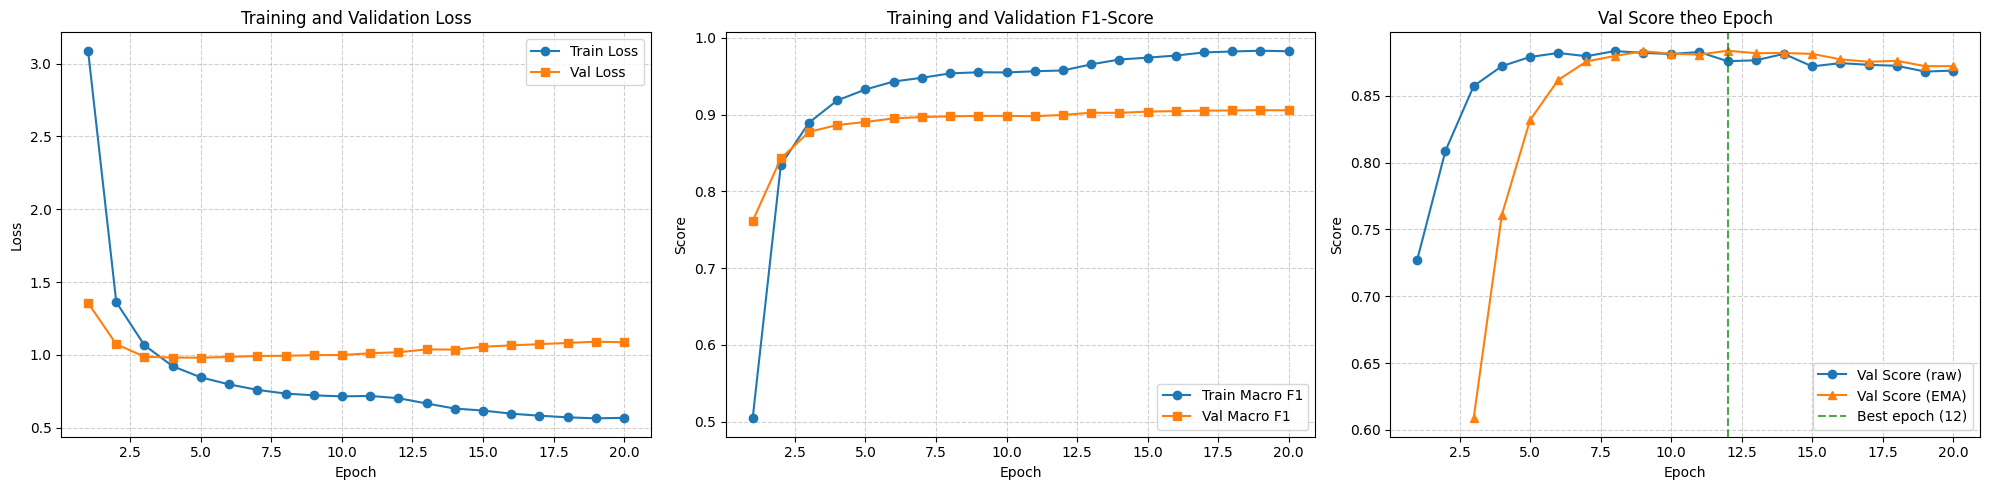


Đang nạp mô hình...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Nạp thành công trọng số từ best_phobert_absa_v25_07.pth
Đang chạy mô hình trên tập Validation để lấy dự đoán...


100%|██████████| 70/70 [01:02<00:00,  1.13it/s]



     BẢNG MA TRẬN NHẦM LẪN (THEO PHẦN TRĂM %)     

--- NHÃN: FOOD QUALITY ---
                 Dự đoán Negative Dự đoán Neutral Dự đoán Positive
Thực tế Negative            86.6%           12.8%             0.5%
Thực tế Neutral              9.3%           84.1%             6.6%
Thực tế Positive             0.4%            4.4%            95.2%

--- NHÃN: PRICE ---
                 Dự đoán Negative Dự đoán Neutral Dự đoán Positive
Thực tế Negative            90.6%            6.2%             3.1%
Thực tế Neutral              1.3%           96.3%             2.4%
Thực tế Positive             1.5%            3.7%            94.8%

--- NHÃN: SERVICE QUALITY ---
                 Dự đoán Negative Dự đoán Neutral Dự đoán Positive
Thực tế Negative            91.0%            7.4%             1.7%
Thực tế Neutral              5.3%           90.5%             4.2%
Thực tế Positive             0.8%            3.9%            95.3%

--- NHÃN: ATMOSPHERE ---
                 Dự đoán Negative Dự đ

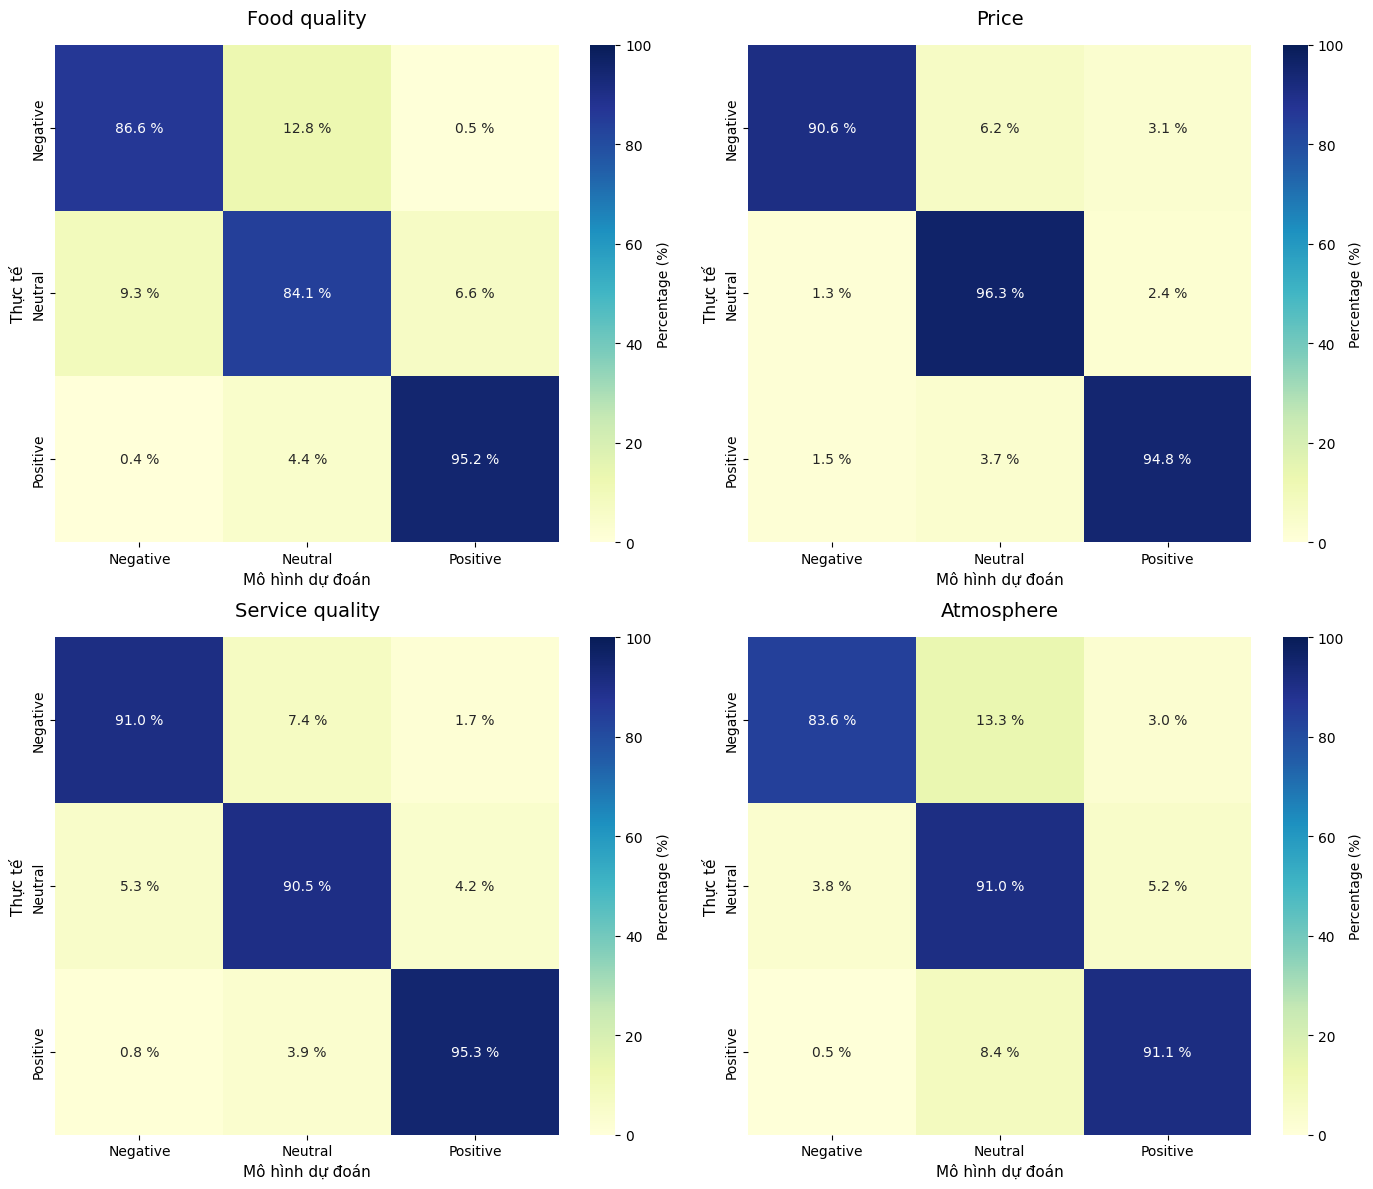

In [2]:
import json
import warnings
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")

# ================= CÁC THÔNG SỐ CẦN KHỚP VỚI LÚC TRAIN =================
MODEL_NAME = "vinai/phobert-base-v2"
DATA_FILE = "labeled_results_all_v6.json"
CHECKPOINT_PATH = "best_phobert_absa_v25_07.pth"
REPORT_PATH = "master_25_07_report.json"

ASPECTS = ["Food quality", "Price", "Service quality", "Atmosphere"]
CLASS_NAMES = ["Negative", "Neutral", "Positive"]
MAX_LEN = 256
BATCH_SIZE = 64
USE_HIDDEN_FUSION = True
# =======================================================================


class PhoBertABSA(nn.Module):
    def __init__(self, model_name: str, n_classes: int = 3, n_aspects: int = 4,
                 hidden_projection_size: int = 256, dropout_projection: float = 0.35,
                 dropout_multisample: Tuple[float, float, float] = (0.15, 0.25, 0.35),
                 use_hidden_fusion: bool = False):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.use_hidden_fusion = use_hidden_fusion
        hidden_size = self.phobert.config.hidden_size

        self.aspect_attentions = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.Tanh(), nn.Linear(hidden_size, 1))
            for _ in range(n_aspects)
        ])

        self.aspect_projections = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_size * 2, hidden_projection_size),
                nn.LayerNorm(hidden_projection_size),
                nn.GELU(),
                nn.Dropout(dropout_projection),
            ) for _ in range(n_aspects)
        ])

        self.dropouts = nn.ModuleList([nn.Dropout(p=p) for p in dropout_multisample])
        self.classifiers = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_projection_size, n_classes)) for _ in range(n_aspects)
        ])

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor, return_views: bool = False):
        if self.use_hidden_fusion:
            outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
            last_4_layers = outputs.hidden_states[-4:]
            last_hidden = torch.stack(last_4_layers, dim=0).mean(dim=0)
        else:
            outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden = outputs.last_hidden_state
        cls_pooled = last_hidden[:, 0, :]
        mask = attention_mask.unsqueeze(-1).float()

        logits: List[torch.Tensor] = []
        view_logits: Optional[List[torch.Tensor]] = [] if return_views else None
        for aspect_idx in range(len(self.aspect_projections)):
            attn_weights = self.aspect_attentions[aspect_idx](last_hidden)
            attn_weights = attn_weights.masked_fill(mask == 0, -1e9)
            attn_weights = F.softmax(attn_weights, dim=1)
            aspect_pooled = torch.sum(attn_weights * last_hidden, dim=1)
            fused = torch.cat([cls_pooled, aspect_pooled], dim=-1)
            aspect_repr = self.aspect_projections[aspect_idx](fused)
            stacked = torch.stack([self.classifiers[aspect_idx](drop(aspect_repr)) for drop in self.dropouts], dim=0)
            logits.append(stacked.mean(dim=0))
            if return_views:
                view_logits.append(stacked)
        if return_views:
            return logits, view_logits
        return logits


def map_label(value: float) -> int:
    if value == 0.0: return 0
    if value == 0.5: return 1
    if value == 1.0: return 2
    return 1


class DatasetEval(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts = df["text"].values
        self.labels = df[ASPECTS].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), add_special_tokens=True, max_length=self.max_len,
                             padding="max_length", truncation=True, return_attention_mask=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].flatten(), "attention_mask": enc["attention_mask"].flatten(),
                "labels": torch.tensor(self.labels[idx], dtype=torch.long)}


def get_val_loader():
    with open(DATA_FILE, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
    processed = []
    for item in raw_data:
        labels = {entry["name"]: map_label(entry["value"]) for entry in item["labels"]}
        processed.append({
            "text": item["original_data"]["textTranslated"],
            "Food quality": labels.get("Food quality", 1),
            "Price": labels.get("Price", 1),
            "Service quality": labels.get("Service quality", 1),
            "Atmosphere": labels.get("Atmosphere", 1),
        })
    df = pd.DataFrame(processed)
    df["stratify_key"] = df[ASPECTS].astype(str).agg("_".join, axis=1)

    if df["stratify_key"].value_counts().min() < 2:
        stratify_key = df["Atmosphere"].astype(str)
    else:
        stratify_key = df["stratify_key"]

    _, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=stratify_key)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    val_dataset = DatasetEval(val_df.reset_index(drop=True), tokenizer, MAX_LEN)
    return DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


def plot_history(report_path: str):
    try:
        with open(report_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        history = data["history"]
        total_epochs_run = data.get("total_epochs_run", len(history["train_loss"]))
        best_epoch = data.get("best_epoch")
        best_source = data.get("best_source", "raw")
        epochs = range(1, len(history["train_loss"]) + 1)

        print(f"Report ghi nhận {len(history['train_loss'])}/{total_epochs_run} epoch "
              f"(best_epoch={best_epoch}, nguồn checkpoint tốt nhất='{best_source}').")

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))

        axes[0].plot(epochs, history["train_loss"], label='Train Loss', marker='o')
        axes[0].plot(epochs, history["val_loss"], label='Val Loss', marker='s')
        axes[0].set_title('Training and Validation Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        axes[1].plot(epochs, history["train_macro_f1"], label='Train Macro F1', marker='o')
        axes[1].plot(epochs, history["val_macro_f1"], label='Val Macro F1', marker='s')
        axes[1].set_title('Training and Validation F1-Score')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Score')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        axes[2].plot(epochs, history["val_score"], label='Val Score (raw)', marker='o')
        if "val_score_ema" in history and any(v is not None for v in history["val_score_ema"]):
            ema_epochs = [e for e, v in zip(epochs, history["val_score_ema"]) if v is not None]
            ema_values = [v for v in history["val_score_ema"] if v is not None]
            axes[2].plot(ema_epochs, ema_values, label='Val Score (EMA)', marker='^')
        if best_epoch:
            axes[2].axvline(x=best_epoch, color="green", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
        axes[2].set_title('Val Score theo Epoch')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Score')
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.savefig("history_curves_v25_07.png", dpi=200)
        print("Đã lưu biểu đồ history tại: history_curves_v25_07.png")
        plt.show()
    except Exception as e:
        print(f"Không thể vẽ biểu đồ History (lỗi đọc JSON): {e}")


def plot_and_print_percentage_cm(model, val_loader, device):
    model.eval()
    all_preds = {aspect: [] for aspect in ASPECTS}
    all_targets = {aspect: [] for aspect in ASPECTS}

    print("Đang chạy mô hình trên tập Validation để lấy dự đoán...")
    with torch.no_grad():
        for batch in tqdm(val_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            logits = model(input_ids, attention_mask)

            for aspect_idx, aspect in enumerate(ASPECTS):
                preds = torch.argmax(logits[aspect_idx], dim=1).cpu().tolist()
                all_preds[aspect].extend(preds)
                all_targets[aspect].extend(labels[:, aspect_idx].tolist())

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    print("\n" + "="*50)
    print(" BẢNG MA TRẬN NHẦM LẪN (THEO PHẦN TRĂM %)".center(50))
    print("="*50)

    for idx, aspect in enumerate(ASPECTS):
        cm = confusion_matrix(all_targets[aspect], all_preds[aspect], labels=[0, 1, 2])

        row_sums = cm.sum(axis=1)[:, np.newaxis]
        row_sums[row_sums == 0] = 1
        cm_pct = (cm.astype(float) / row_sums) * 100

        print(f"\n--- NHÃN: {aspect.upper()} ---")
        df_cm = pd.DataFrame(
            cm_pct,
            index=[f"Thực tế {c}" for c in CLASS_NAMES],
            columns=[f"Dự đoán {c}" for c in CLASS_NAMES]
        )
        print(df_cm.map(lambda x: f"{x:.1f}%"))

        ax = axes[idx]
        sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)

        for t in ax.texts: t.set_text(t.get_text() + " %")

        ax.set_title(f"{aspect}", fontsize=14, pad=15)
        ax.set_xlabel("Mô hình dự đoán", fontsize=11)
        ax.set_ylabel("Thực tế", fontsize=11)

    plt.tight_layout()
    plt.savefig("percentage_confusion_matrix_v25_07.png", dpi=200, bbox_inches="tight")
    print("\nĐã lưu ảnh Ma trận nhầm lẫn phần trăm tại: percentage_confusion_matrix_v25_07.png")
    plt.show()


def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    plot_history(REPORT_PATH)

    print("\nĐang nạp mô hình...")
    model = PhoBertABSA(MODEL_NAME, use_hidden_fusion=USE_HIDDEN_FUSION).to(device)
    try:
        model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
        print(f"Nạp thành công trọng số từ {CHECKPOINT_PATH}")
    except Exception as e:
        print(f"Lỗi nạp weights. Hãy kiểm tra lại đường dẫn CHECKPOINT_PATH. Lỗi: {e}")
        return

    val_loader = get_val_loader()
    plot_and_print_percentage_cm(model, val_loader, device)


if __name__ == "__main__":
    main()
